TITLE:            Example graph of precipitation 
PROJECT:          "Climate analogs under SAI"
AUTHORS:          Ruoyu Chen
COLLABORATORS:    
DATA INPUT:       Global precipitation information as netCDF file
                   
DATA OUTPUT:      Global figure of precipitation and figure cropped around Michigan
DATE:             initiated: 2 June 2026; last run: ____
OVERVIEW:         _____ 
REQUIRES:         precip_indices_001.nc
NOTES:            None

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import geopandas as gpd
import earthpy as et
import xarray as xr
# Spatial subsetting of netcdf files
import regionmask


# Plotting options
sns.set(font_scale=1.3)
sns.set_style("white")


import warnings
warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API.*",
    category=UserWarning
)

import earthpy as et

/mnt/home/f0113797/.conda/envs/testgeo4/lib/python3.14/site-packages/earthpy/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_string


In [2]:
path_file = "/mnt/research/nasabio/data/climate/L1/SSP245/PRECT/precip_indices_001.nc"
precip_info = xr.open_dataset(path_file)


#basic information stored in the file
precip_info 

<xarray.Dataset> Size: 53MB
Dimensions:  (year: 60, lat: 192, lon: 288)
Coordinates:
  * year     (year) int64 480B 2015 2016 2017 2018 2019 ... 2071 2072 2073 2074
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Data variables:
    CDD      (year, lat, lon) float32 13MB ...
    CWD      (year, lat, lon) float32 13MB ...
    PRCPTOT  (year, lat, lon) float32 13MB ...
    R95pTOT  (year, lat, lon) float32 13MB ...
Attributes:
    scenario:                  SSP245
    member:                    001
    variable:                  PRECT
    clim_reference:            SSP245 2015-2034
    wet_day_threshold_mm_day:  1.0
    source_unit_conversion:    PRECT [m/s] x 86400 x 1000 -> mm/day

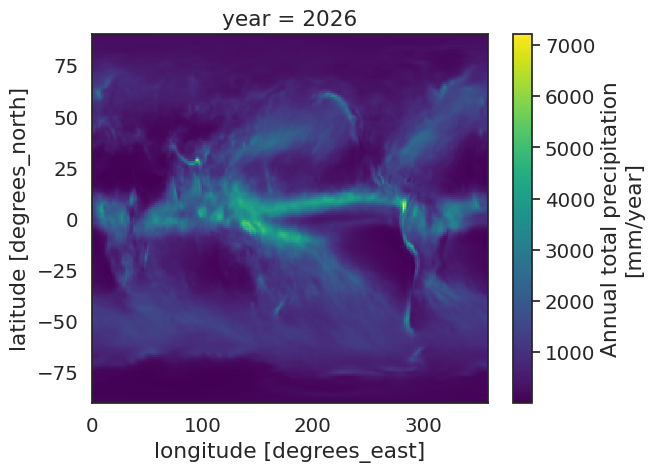

In [3]:
slice_2026 = precip_info["PRCPTOT"].sel(year = slice(2026, 2026))

#Graph of total perciptiation in 2026
slice_2026.plot()

[-95.53143816  40.02500506 -80.51387055  49.38562003]
[264.4685618437541, 279.48612945211255] [40.02500505883643, 49.38562003233869]


<Axes: >

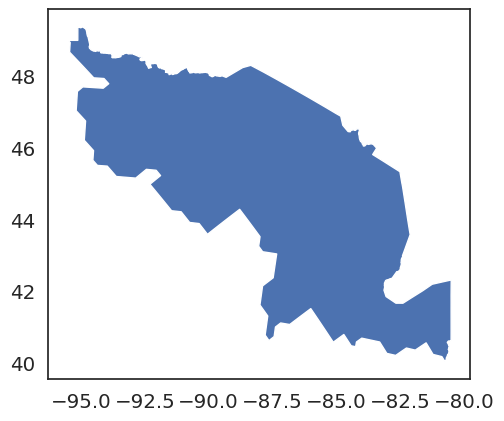

In [4]:
#Masking with the Great Lakes NEON Domain (5)
mask_path = "/mnt/research/nasabio/data/neon_domains/NEON_Domains.shp"

NEON_sites = gpd.read_file(mask_path)
NEON_sites.head()
great_lakes = NEON_sites[NEON_sites.domainName == "Great Lakes"]

print(great_lakes.total_bounds)
#We need to change these coordinates, with negative longitude, to the ones that the netcdf file uses, because it is always positive.
lon = [float(great_lakes.total_bounds[0]) + 360, float(great_lakes.total_bounds[2]) + 360]
lat = [float(great_lakes.total_bounds[1]), float(great_lakes.total_bounds[3])]
print(lon, lat)


great_lakes.plot()

#Shows the mask of the great lakes region. 

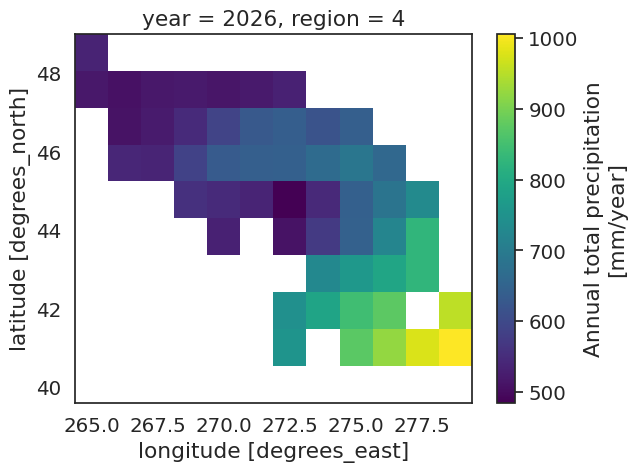

In [5]:
#Creating the Great Lakes mask
greatlakes_mask = regionmask.mask_3D_geopandas(great_lakes, precip_info.lon, precip_info.lat)

slice_2026_mask = precip_info["PRCPTOT"].sel(year = slice(2026, 2026), lon=slice(lon[0],
                                                                              lon[1]),
                                                                    lat=slice(lat[0],
                                                                              lat[1])).where(greatlakes_mask)

#Graph of total perciptiation in 2026
slice_2026_mask.plot()

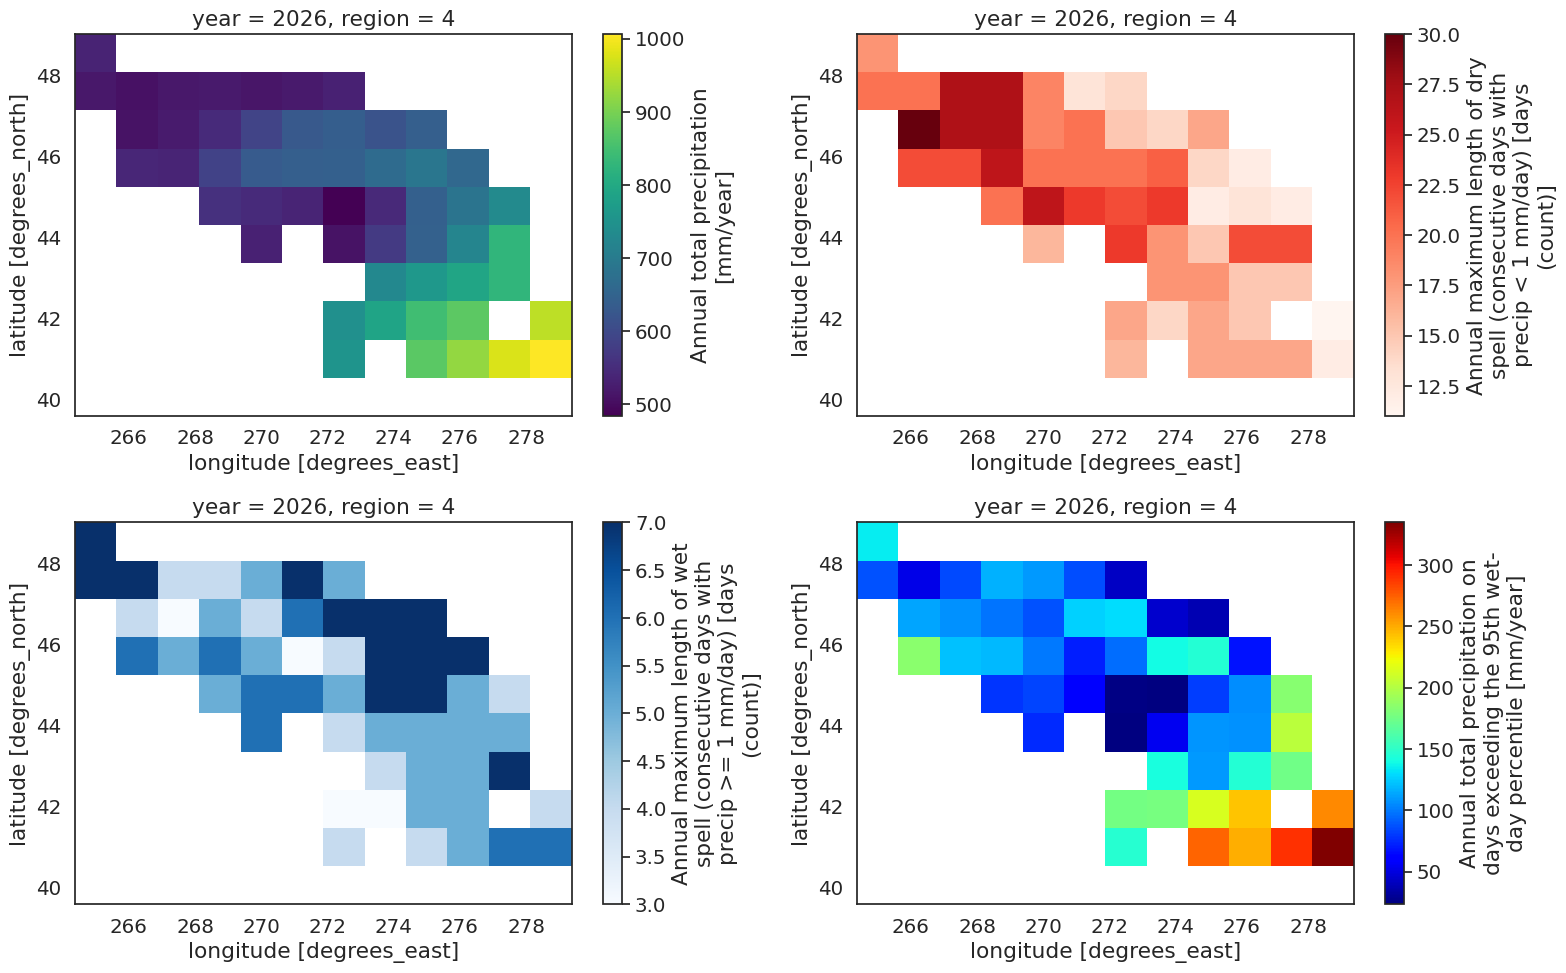

In [9]:
#Creating a few different graphs for CDD, CWD, PRCPTOT, and R95pTOT with color schemes

fig, axs = plt.subplots(2, 2,  figsize=(16, 10))


#Graph of total annual perciptiation in 2026
slice_2026_mask = precip_info["PRCPTOT"].sel(year = slice(2026, 2026), lon=slice(lon[0],
                                                                              lon[1]),
                                                                    lat=slice(lat[0],
                                                                              lat[1])).where(greatlakes_mask)

slice_2026_mask.plot(col_wrap = 2, ax = axs[0, 0])

#Graph of Consecutive Dry Days in 2026
slice_2026_mask_cdd = precip_info["CDD"].sel(year = slice(2026, 2026), lon=slice(lon[0],
                                                                              lon[1]),
                                                                    lat=slice(lat[0],
                                                                              lat[1])).where(greatlakes_mask)
slice_2026_mask_cdd.plot(col_wrap = 2, cmap = "Reds", ax = axs[0, 1])

#Graph of Consecutive Wet Days in 2026
slice_2026_mask_cwd = precip_info["CWD"].sel(year = slice(2026, 2026), lon=slice(lon[0],
                                                                              lon[1]),
                                                                    lat=slice(lat[0],
                                                                              lat[1])).where(greatlakes_mask)

slice_2026_mask_cwd.plot(col_wrap = 2, ax = axs[1, 0], cmap = "Blues")

#Graph of total precip exceeding 95th precentile in 2026
slice_2026_mask_95 = precip_info["R95pTOT"].sel(year = slice(2026, 2026), lon=slice(lon[0],
                                                                              lon[1]),
                                                                    lat=slice(lat[0],
                                                                              lat[1])).where(greatlakes_mask)
slice_2026_mask_95.plot(col_wrap = 2, ax = axs[1, 1], cmap = "jet")
plt.tight_layout()

plt.savefig("/mnt/home/f0113797/Documents/climate_analogs/Python/L0/plots/precip_plots.jpg")

plt.show()